# Challenge 2

This challenge is about OSMnx. You will explore and analyze a city's street network using the OSMnx Python library.

1. Use OSMnx to download the street network of a city of your choice. You can specify the city name, BBox or a Dict.
2. Calculate basic statistics for the street network, such as the number of nodes, edges, average node degree, etc.
3. Use OSMnx to plot the street network. Customize the plot to make it visually appealing, including node size, edge color. See the potential options here: https://osmnx.readthedocs.io/en/stable/user-reference.html#module-osmnx.plot
4. Utilize the routing capabilities of OSMnx to find the shortest path between two points in the street network. Plot the route on top of the street network.
5. Calculate the centrality measures (e.g., degree centrality and betweenness_centrality) for nodes in the street network.
6. Create the figure-groud from the selected city
7. Create interactive maps to plot nodes, edges, nodes+edges and one of the centrality measures.
8. Export the street network to a GeoPackage (.gpkg) file. Ensure that the exported file contains both node and edge attributes. Demonstrate that the new GeoPackage can be used and read in Python using any of the libraries we have seen in the class to create a simple and interactive map.
9. Finally, use OSMnx to extract other urban elements (e.g., buildings, parks) and plot them.

In [1]:
import networkx as nx
import osmnx as ox

In [2]:
#pip install --upgrade ipykernel

In [3]:
#downloading our chosen street network of San Diego
# through making a query in the form of a dict
place = {"city": "San Diego", "state": "California", "country": "USA"}
G = ox.graph_from_place(place, network_type="drive", truncate_by_edge=True)

In [4]:
#calculating basic statistics for the street network, such as number of nodes, edges, average node degree etc.

In [5]:
#calculating number of nodes
print("The graph has", len(G.nodes), "nodes")

#calculating number of edges
print("The graph has", len(G.edges), "edges")

The graph has 27324 nodes
The graph has 66938 edges


In [6]:
#exploring the data type of nodes
print("The nodes are", print(type(G.nodes)))

<class 'networkx.classes.reportviews.NodeView'>
The nodes are None


In [7]:
#exploring the data type of edges
print("The edges are", print(type(list(G.edges(data=True))[0])))

<class 'tuple'>
The edges are None


In [8]:
#exploring elements of the first and last nodes
print(list(G.nodes(data=True))[0])
print(list(G.nodes(data=True))[-1])

(48857412, {'y': 32.823986, 'x': -117.100731, 'street_count': 3})
(12658070290, {'y': 32.8923715, 'x': -117.1639653, 'street_count': 3})


In [9]:
#exploring elements of the first and last edges
print(list(G.edges(data=True))[0])
print(list(G.edges(data=True))[-1])

(48857412, 1429663812, {'osmid': 5938355, 'highway': 'residential', 'name': 'Esplendente Boulevard', 'oneway': False, 'reversed': True, 'length': np.float64(93.31255574856051), 'geometry': <LINESTRING (-117.101 32.824, -117.101 32.824, -117.101 32.823, -117.101 32....>})
(12658070290, 12658070289, {'osmid': 1366759952, 'highway': 'residential', 'oneway': False, 'reversed': True, 'length': np.float64(6.872235776676256)})


In [10]:
#calculating average node degree 
#warning - very large cell output
nx.average_neighbor_degree(G, weight="weight")

{48857412: 3.6666666666666665,
 48857474: 3.0,
 48857477: 2.6666666666666665,
 48857561: 3.0,
 48857565: 2.3333333333333335,
 48857569: 3.0,
 48857571: 3.3333333333333335,
 48857572: 3.0,
 48857574: 4.0,
 48857575: 2.25,
 48857790: 2.3333333333333335,
 48858312: 1.0,
 48858427: 1.0,
 48858432: 2.0,
 48858442: 1.5,
 48858446: 1.0,
 48859391: 2.0,
 48859410: 1.0,
 48859930: 2.3333333333333335,
 48859934: 3.0,
 48860023: 2.0,
 48860025: 3.3333333333333335,
 48860026: 3.0,
 48860027: 3.3333333333333335,
 48860028: 3.3333333333333335,
 48860101: 3.3333333333333335,
 48860102: 3.0,
 48860103: 3.0,
 48860104: 3.0,
 48860105: 3.0,
 48860245: 1.6666666666666667,
 48860268: 2.0,
 48860271: 1.5,
 48860275: 1.5,
 48860707: 2.3333333333333335,
 48860940: 2.5,
 48860946: 1.0,
 48860969: 2.0,
 48860973: 2.0,
 48861551: 2.0,
 48861555: 1.5,
 48861559: 2.0,
 48861601: 2.0,
 48861750: 2.0,
 48861754: 1.5,
 48861763: 2.5,
 48861997: 1.0,
 48862002: 2.0,
 48862264: 2.3333333333333335,
 48862271: 3.0,
 488

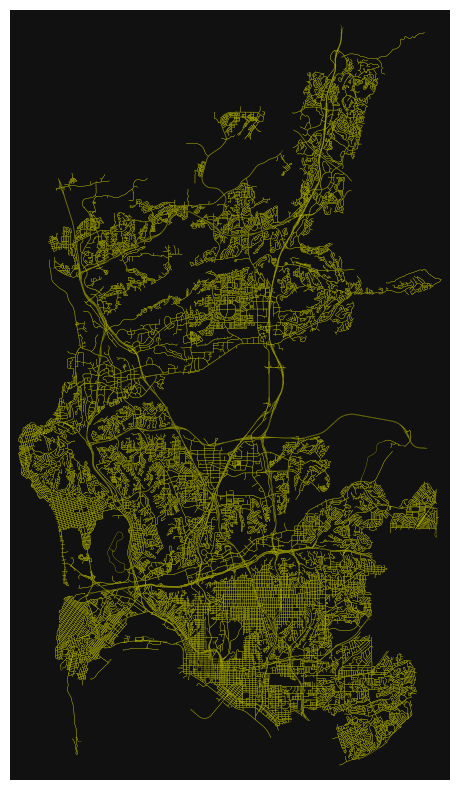

In [11]:
#plotting street network using OSMnx
fig, ax = ox.plot_graph(G, figsize=(10, 10), node_size=0, edge_color="y", edge_linewidth=0.2)

In [12]:
#customising the node size and edge color

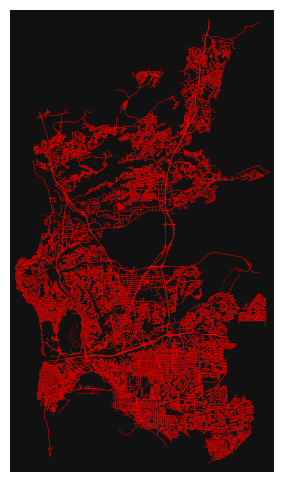

In [13]:
#first experiment, changing the color and figure size
fig, ax = ox.plot_graph(G, figsize=(6, 6), node_size=0, edge_color="r", edge_linewidth=0.2)

In [14]:
#second experiment, visualising street centrality using color
#defining edge centrality and ev
edge_centrality = nx.closeness_centrality(nx.line_graph(G))
ev = [edge_centrality[edge + (0,)] for edge in G.edges()]

#converting the color scale to a list of colors for graph edges
norm = colors.Normalize(vmin=min(ev)*0.8, vmax=max(ev))
cmap = cm.ScalarMappable(norm=norm, cmap=cm.inferno)
ec = [cmap.to_rgba(cl) for cl in ev]

# coloring the edges with closeness centralities in the line graph
fig, ax = ox.plot_graph(G, bgcolor='k', axis_off=True, node_size=0,
                        edge_color=ec, edge_linewidth=1.5, edge_alpha=1)


KeyboardInterrupt



Reference: gboeing (2017). osmnx-examples/notebooks/00-osmnx-features-demo.ipynb at v0.13.0 · gboeing/osmnx-examples. [online] GitHub. Available at: https://github.com/gboeing/osmnx-examples/blob/v0.13.0/notebooks/00-osmnx-features-demo.ipynb [Accessed 16 Mar. 2025].

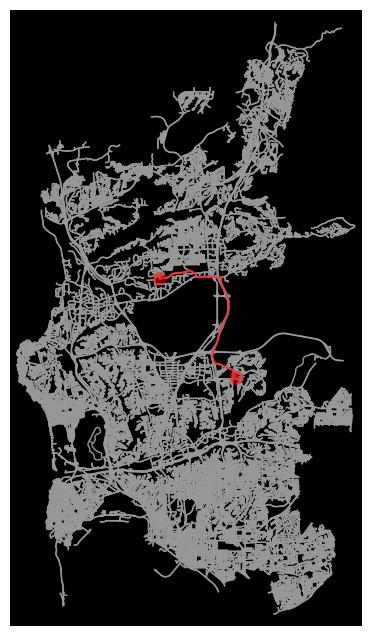

In [15]:
#utilise the routing capabilities of OSMnx to find the shortest path between two points 

#establishing origin
orig = list(G)[0]

#establishing destination
dest = list(G)[-1]

#plot the route
route = nx.shortest_path(G, orig, dest, weight='length')
fig, ax = ox.plot_graph_route(G, route, route_linewidth=2, node_size=0, bgcolor='k')

Reference: Geoff Boeing. (2016). OSMnx: Python for Street Networks. [online] Available at: https://geoffboeing.com/2016/11/osmnx-python-street-networks/.

In [ ]:
#calculating centrality measures
#calculating degree centrality
degree_centrality = nx.degree_centrality(G)
for node, centrality in degree_centrality.items():
    print(f"Node {node}: Degree Centrality = {centrality: .3f}")
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=700, node_color='skyblue')
plt.title('Graph G with Degree Centrality')
plt.show()

#calculating betweenness centrality
extended_stats = ox.extended_stats(G, bc=True)
print(extended_stats['betweenness_centrality_avg'])

In [ ]:
#creating figure-ground diagram from San Diego
import osmnx as ox
from IPython.display import Image

#configuring the inline image display
img_folder = "images"
extension = "png"
size = 240
dpi = 40

#picking a point in San Diego to display
place = 'san diego'
point=(32.823986, -117.100731)
fig, ax = ox.plot_figure_ground(point=point, filename=place, dpi=dpi)
Image('{}/{}.{}'.format(img_folder, place, extension), height=size, width=size)

Reference: gboeing (2017). osmnx-examples/notebooks/09-example-figure-ground.ipynb at v0.11 · gboeing/osmnx-examples. [online] GitHub. Available at: https://github.com/gboeing/osmnx-examples/blob/v0.11/notebooks/09-example-figure-ground.ipynb [Accessed 16 Mar. 2025].

In [ ]:
#creating interactive maps to plot nodes, edges, nodes+edges and one of centrality measures

In [ ]:
warnings.filterwarnings('ignore')
# downloading a street network then solve a shortest-path route on it
weight = "length"
G = ox.graph_from_place("Sunset Blvd, San Diego", network_type="drive")
orig = list(G.nodes)[0]
dest = list(G.nodes)[-1]
route = ox.shortest_path(G, orig, dest, weight=weight)

In [ ]:
# exploring graph edges interactively, with a simple one-liner
ox.graph_to_gdfs(G, nodes=False).explore()

In [ ]:
# exploring graph nodes interactively, with different basemap tiles
nodes = ox.graph_to_gdfs(G, edges=False)
nodes.explore(tiles="cartodbpositron", marker_kwds={"radius": 8})

In [ ]:
# exploring nodes and edges together in a single map
nodes, edges = ox.graph_to_gdfs(G)
m = edges.explore(color="skyblue", tiles="cartodbdarkmatter")
nodes.explore(m=m, color="pink", marker_kwds={"radius": 6})

In [ ]:
# exploring graph edges interactively, colored by length
edges.explore(tiles="cartodbdarkmatter", column="length", cmap="plasma")

In [ ]:
# exploring graph nodes interactively, colored by betweenness centrality
nx.set_node_attributes(G, nx.betweenness_centrality(G, weight="length"), name="bc")
nodes = ox.graph_to_gdfs(G, edges=False)
nodes.explore(tiles="cartodbdarkmatter", column="bc", marker_kwds={"radius": 8})

In [ ]:
#exporting street network to a geopackage file
x.save_graph_geopackage(G, filepath="./data/mynetwork.gpkg")
ox.save_graphml(G, filepath="./data/mynetwork.graphml")

In [ ]:
#reading the geopackage file in python
read = "./data/mynetwork.gpkg"

In [ ]:
#using OSMnx to extract other urban elements e.g. buildings, parks and plotting them
osmnx.features.features_from_address(str, building, float)